<a href="https://colab.research.google.com/github/derekwang8/undergrad_ml_assignments/blob/main/genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("/content/golub.csv")

df["cancer"] = df["cancer"].str.lower()
label_map = {"allb": 0, "allt": 0, "aml": 1}
df["target"] = df["cancer"].map(label_map)

X = df.iloc[:, 6:].copy()
y = df["target"].values

print("Shape of X:", X.shape)
print("Target counts:\n", df["target"].value_counts())

Shape of X: (72, 7130)
Target counts:
 target
0    47
1    25
Name: count, dtype: int64


Q2 - Linear Regression Training MSE: 1.2069160984826679e-30


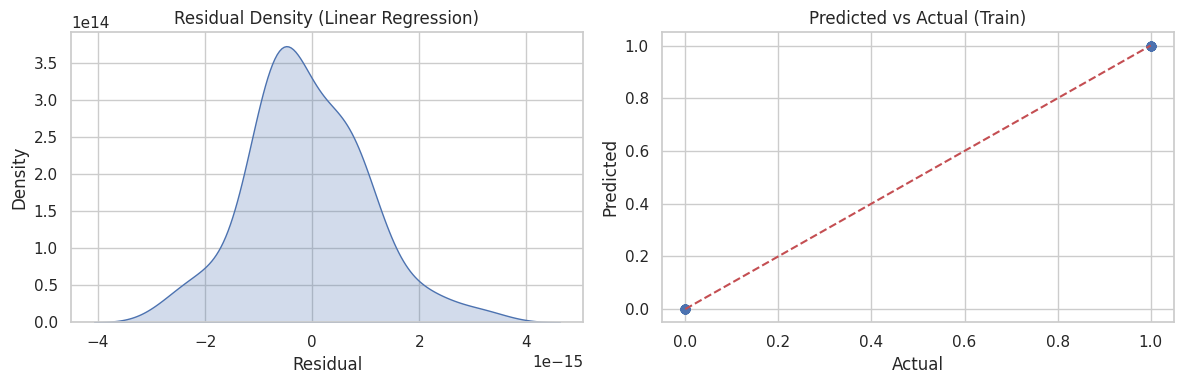

In [4]:
linreg = LinearRegression()
linreg.fit(X, y)

y_pred_train = linreg.predict(X)
mse_train = mean_squared_error(y, y_pred_train)
residuals = y - y_pred_train

print("Q2 - Linear Regression Training MSE:", mse_train)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(residuals, fill=True, ax=ax[0])
ax[0].set_title("Residual Density (Linear Regression)")
ax[0].set_xlabel("Residual")

ax[1].scatter(y, y_pred_train, alpha=0.8)
ax[1].plot([0, 1], [0, 1], "r--")
ax[1].set_title("Predicted vs Actual (Train)")
ax[1].set_xlabel("Actual")
ax[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

In [5]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_neg_mse = cross_val_score(linreg, X, y, cv=kf, scoring="neg_mean_squared_error")
cv_mse = -cv_neg_mse

print("Q3 - CV MSEs:", np.round(cv_mse, 4))
print("Q3 - Mean CV MSE:", cv_mse.mean())
print("Q3 - Std CV MSE:", cv_mse.std())


Q3 - CV MSEs: [0.046  0.0423 0.0482 0.0794 0.0158 0.0759 0.0667 0.0387 0.0188 0.0279]
Q3 - Mean CV MSE: 0.045965859349167276
Q3 - Std CV MSE: 0.02119711109108409


Q4 - Best alpha: 0.0004760871250278503
Q4 - Number of selected genes: 1
Q4 - Number of discarded genes: 7129

Q4 - Selected genes:
['target']


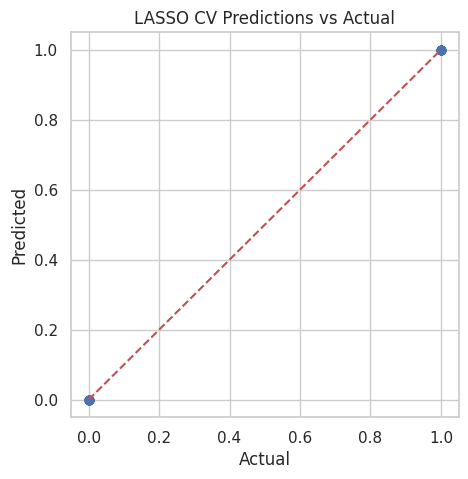

In [6]:
lasso_pipe = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=20000, n_alphas=100)
)
lasso_pipe.fit(X, y)

lasso_cv = lasso_pipe.named_steps["lassocv"]
coef = lasso_cv.coef_
selected_mask = coef != 0
selected_genes = X.columns[selected_mask].tolist()

print("Q4 - Best alpha:", lasso_cv.alpha_)
print("Q4 - Number of selected genes:", len(selected_genes))
print("Q4 - Number of discarded genes:", X.shape[1] - len(selected_genes))
print("\nQ4 - Selected genes:")
print(selected_genes)

# CV predictions for fair scatterplot
lasso_cv_preds = cross_val_predict(lasso_pipe, X, y, cv=kf)

plt.figure(figsize=(5, 5))
plt.scatter(y, lasso_cv_preds, alpha=0.8)
plt.plot([0, 1], [0, 1], "r--")
plt.title("LASSO CV Predictions vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


Q5 - Optimal alpha: 0.0004760871250278503
Q5 - Minimum CV MSE: 3.523757378473331e-07


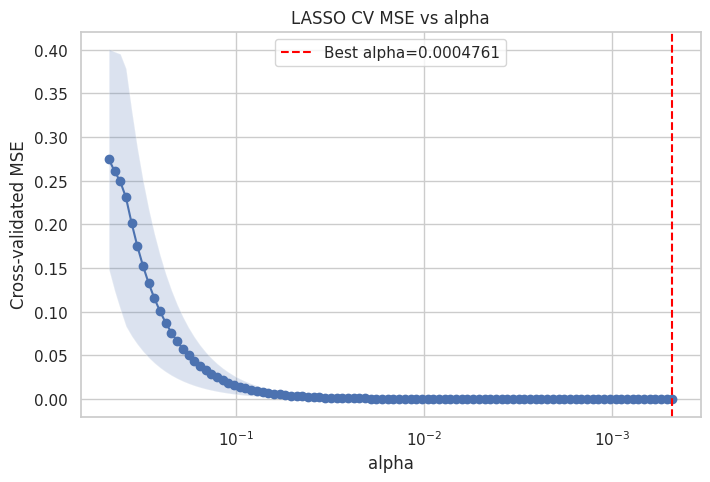

Likely underfitting at larger alpha values (left side of plot).
Likely overfitting at very small alpha values (right side of plot).


In [7]:
mean_mse_path = lasso_cv.mse_path_.mean(axis=1)
std_mse_path = lasso_cv.mse_path_.std(axis=1)
alphas = lasso_cv.alphas_

best_idx = np.argmin(mean_mse_path)
best_alpha = alphas[best_idx]
best_mse = mean_mse_path[best_idx]

print("Q5 - Optimal alpha:", best_alpha)
print("Q5 - Minimum CV MSE:", best_mse)

# Simple underfit/overfit identification relative to minimum
underfit_alphas = alphas[alphas > best_alpha]
overfit_alphas = alphas[alphas < best_alpha]

plt.figure(figsize=(8, 5))
plt.semilogx(alphas, mean_mse_path, marker="o")
plt.fill_between(
    alphas,
    mean_mse_path - std_mse_path,
    mean_mse_path + std_mse_path,
    alpha=0.2
)
plt.axvline(best_alpha, color="red", linestyle="--", label=f"Best alpha={best_alpha:.4g}")
plt.gca().invert_xaxis()  # higher alpha on left (common LASSO plot style)
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("LASSO CV MSE vs alpha")
plt.legend()
plt.show()

print("Likely underfitting at larger alpha values (left side of plot).")
print("Likely overfitting at very small alpha values (right side of plot).")


In [8]:
lin_train_mse = mean_squared_error(y, y_pred_train)
lasso_train_pred = lasso_pipe.predict(X)
lasso_train_mse = mean_squared_error(y, lasso_train_pred)
lasso_cv_mse = mean_squared_error(y, lasso_cv_preds)

print("Linear train MSE:", lin_train_mse)
print("Linear 10-fold CV mean MSE:", cv_mse.mean())
print("LASSO train MSE:", lasso_train_mse)
print("LASSO CV-prediction MSE:", lasso_cv_mse)
print("Best LASSO alpha:", lasso_cv.alpha_)
print("Selected genes:", len(selected_genes))
print("Discarded genes:", X.shape[1] - len(selected_genes))


Linear train MSE: 1.2069160984826679e-30
Linear 10-fold CV mean MSE: 0.045965859349167276
LASSO train MSE: 2.2665895061723402e-07
LASSO CV-prediction MSE: 2.3540332480685875e-07
Best LASSO alpha: 0.0004760871250278503
Selected genes: 1
Discarded genes: 7129


**Q6.**

With thousands of genes and only dozens of patients, ordinary linear regression has enough flexibility to nearly interpolate the training set (very low training error), but this causes high variance and weaker generalization. LASSO adds an L1 penalty that shrinks many coefficients to zero, reducing complexity and improving out-of-sample performance.

**Q7.**  
Precision-health datasets are often high-dimensional, noisy, and small-sample. Regularization helps control overfitting, improves model stability, and produces sparse models that are easier to interpret biologically and clinically.

**Q8.**  
LASSO can miss weak but important signals, be unstable with correlated genes, and reflect dataset bias. If used without external validation and clinical oversight, it can lead to incorrect or unfair intervention decisions.
